## Case Study - Household response to inflation 

## Imports and global style

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns 
from scipy import stats

%matplotlib inline 

plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['font.family'] = 'sans-serif'

ALPHA = 0.05

print('Imports - successful!')
print(f'Significance level (alpha) set to: {ALPHA}')

Imports - successful!
Significance level (alpha) set to: 0.05


## Data Import

In [2]:
df = pd.read_csv('topic6_147200_147650.csv')
print('Data import - successful\n')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print()
df.head(int(30))



Data import - successful

Shape: (2000, 14)

Columns: ['group_number', 'student1_id', 'student2_id', 'selected_countries', 'country_code', 'age_group', 'income', 'price_past', 'price_exp', 'sit_last_12months', 'sit_next_12months', 'reduced_consumption', 'increased_income', 'increased_spending']



,group_number,student1_id,student2_id,selected_countries,country_code,age_group,income,price_past,price_exp,sit_last_12months,sit_next_12months,reduced_consumption,increased_income,increased_spending
0,21,147200,147650,"ES, EL, PT, DE",DE,35-49,Second quintile,Prices stayed exactly the same,Prices will increase a little,About the same,About the same,No changes,No changes,No changes
1,21,147200,147650,"ES, EL, PT, DE",DE,35-49,First quintile,Prices went up a lot,Prices will increase a lot,About the same,About the same,No changes,No changes,Yes (purchased durable goods)
2,21,147200,147650,"ES, EL, PT, DE",DE,18-34,Fifth quintile,Prices went down a lot,Prices will decrease a lot,About the same,About the same,No changes,No changes,No changes
3,21,147200,147650,"ES, EL, PT, DE",DE,35-49,Second quintile,Prices went up a little,Prices will increase a little,About the same,About the same,Yes (cheaper or fewer goods),No changes,No changes
4,21,147200,147650,"ES, EL, PT, DE",DE,50-70,Third quintile,Prices went up a little,Prices will increase a little,About the same,About the same,Yes (cheaper or fewer goods),No changes,No changes
5,21,147200,147650,"ES, EL, PT, DE",DE,35-49,Fourth quintile,Prices went down a lot,Prices will increase a little,Somewhat better off,Somewhat better off,No changes,Yes (raise or second job),No changes
6,21,147200,147650,"ES, EL, PT, DE",DE,50-70,Fourth quintile,Prices went up a little,Prices will increase a little,About the same,About the same,No changes,No changes,No changes
7,21,147200,147650,"ES, EL, PT, DE",DE,50-70,Fourth quintile,Prices went up a lot,Prices will increase a little,Somewhat worse off,Somewhat better off,Yes (cheaper or fewer goods),Yes (raise or second job),No changes
8,21,147200,147650,"ES, EL, PT, DE",DE,50-70,Fourth quintile,Prices went up a little,Prices will increase a little,Somewhat better off,About the same,No changes,No changes,No changes
9,21,147200,147650,"ES, EL, PT, DE",DE,50-70,Fifth quintile,Prices went up a little,Prices will increase a little,About the same,About the same,Yes (cheaper or fewer goods),No changes,No changes


## Global variable encodings: 
Due to the fact that most of the data is in ordinal scale (e.g. "Prices want up a lot") we have to assaign ranks to the data in order to use Spearman rank correlation. We use maps to encode text answers from a survey as numbers (1-5).

In [3]:
# Why we assign values (1-5) to our data: our variables are stored as text strings (e.g. 'Prices went up a lot').
# Statistical tests like Spearman correlation and Kruskal-Wallis require numbers.
# We map each text category to an integer 1–5 that preserves the ordinal order.
# The lowest number (1) always represents the most negative outcome.
# the highest number (5) always represents the most positive outcome.


price_past_map={
    'Prices went down a lot': 1,
    'Prices went down little': 2,
    'Prices stayed exactly the same': 3,
    'Prices went up a little': 4,
    'Prices went up a lot': 5
}
price_exp_map={
    'Prices will decrease a lot': 1,
    'Prices will decrease a little': 2,
    'Prices will be exactly the same': 3,
    'Prices will increase a little': 4,
    'Prices will increase a lot': 5
}
sit_map={
    'Much worse off':1,
    'Somewhat worse off':2,
    'About the same':3,
    'Somewhat better off':4,
    'Much better off':5
}
income_map={
    'First quintile':1,
    'Second quintile':2,
    'Third quintile':3,
    'Fourth quintile':4,
    'Fifth quintile':5
}
age_map={
    '18-34':1, 
    '35-49':2,
    '50-70':3,
    '71 and older':4
}

# .map() replaces each text value with its corresponding number using the dictionaries above.
# If a value in the column has no match in the dictionary, it becomes NaN.
# After mapping, run df['col'].isna().sum() to check for NaN — any value > 0
# means a text string did not match and needs fixing in the dictionary.

df['price_past_num'] = df['price_past'].map(price_past_map)
df['price_exp_num'] = df['price_exp'].map(price_exp_map)
df['sit_last_num'] = df['sit_last_12months'].map(sit_map)
df['sit_next_num'] = df['sit_next_12months'].map(sit_map)
df['income_num'] = df['income'].map(income_map)
df['age_num'] = df['age_group'].map(age_map)

# Binary strategy columns: 1 = household adopted this strategy, 0 = did not.
# .astype(int) converts True/False to 1/0 so we can sum them.

df['reduced'] = (df['reduced_consumption'] == 'Yes (cheaper or fewer goods)').astype(int)
df['increased_income'] = (df['increased_income'] == 'Yes (raise or second job)').astype(int)
df['increased_spending'] = (df['increased_spending'] == 'Yes (purchased durable goods)').astype(int)
df['n_strategies'] = df['reduced'] + df['increased_income'] + df['increased_spending']

PAST_ORDER = list(price_past_map.keys())
EXP_ORDER = list(price_exp_map.keys())
INCOME_ORDER = list(income_map.keys())
INCOME_SHORT = ['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Highest)']
AGE_ORDER = list(age_map.keys())
PAST_SHORT = ['Down a lot', 'Down little', 'Same', 'Up a little', 'Up a lot']
EXP_SHORT = ['Down a lot', 'Down a little', 'Same', 'Increase a little', 'Increase a lot']
DIV_COLORS = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']

# Sanity check: confirm no NaN values were introduced by the mapping
nan_counts = df[['price_past_num','price_exp_num','income_num','age_num']].isna().sum()
print('NaN check, should all be 0:')
print(nan_counts)
print()
print('Setup complete. df now has', df.shape[1], 'columns.')

NaN check, should all be 0:
price_past_num    0
price_exp_num     0
income_num        0
age_num           0
dtype: int64

Setup complete. df now has 22 columns.


## Decision whether to use spearman coefficient or Kendall's tau-b test

In [4]:
# Why we run this test?:
# Kendall's tau-b is arguably more appropriate than Spearman's rho for our data because:
#   1. Our variables are 5-point ordinal scales with 2,000 respondents
#      → massive numbers of tied values (e.g. 1,200+ may people chose the same category)
#   2. Kendall's tau-b has a built-in correction for ties in BOTH variables
#   3. It has a cleaner interpretation: P(concordant pair) - P(discordant pair)
#   4. Spearman's rho can be slightly inflated on coarse ordinal scales
#
# We run BOTH and confirm the decision at alpha = 0.05 is identical.
# Spearman rho is reported in the main figures for comparability with the literature;
# Kendall tau-b serves as a robustness check.

test_pairs = [
    ('Income vs past perception', 'income_num', 'price_past_num'),
    ('Income vs future expectation', 'income_num', 'price_exp_num'),
    ('Past vs future (anchoring)', 'price_past_num','price_exp_num'),
    ('Age vs past perception', 'age_num', 'price_past_num'),
    ('Age vs future expectation', 'age_num', 'price_exp_num'),
]

print(f'Significance level: alpha = {ALPHA}')
print()
header = f'{"Comparison":<34} {"Spearman r":>11} {"p":>8} {"Kendall tau-b":>14} {"p":>8} {"Same decision?":>16}'
print(header)
print('-' * len(header))

for label, x, y in test_pairs:
    # stats.spearmanr: measures monotonic association using ranks.
    # Returns rho (correlation coefficient) and p-value.
    # rho = +1 means perfect positive rank agreement
    # rho = -1 means perfect negative rank agreement
    # rho =  0 means no monotonic association
    r_s, p_s = stats.spearmanr(df[x], df[y])

    # stats.kendalltau: measures concordance between pairs of observations.
    # tau-b corrects for ties in both variables — more appropriate for ordinal scales with few categories and many respondents.
    # tau-b is always smaller in magnitude than Spearman rho - it is expected.
    # However it does not mean the relationship is weaker, just differently measured.
    t_k, p_k = stats.kendalltau(df[x], df[y])

    dec_s = 'Reject H0'  if p_s < ALPHA else 'Fail to reject'
    dec_k = 'Reject H0'  if p_k < ALPHA else 'Fail to reject'
    same  = 'YES'        if dec_s == dec_k else 'DIFFERS'
    print(f'{label:<34} {r_s:>11.4f} {p_s:>8.4f} {t_k:>14.4f} {p_k:>8.4f} {same:>16}')


print('\nConclusion: both methods reach the identical decision at alpha =', ALPHA, 'for every test.')
print('Spearman rho is reported in the main figures; Kendall tau-b is the robustness check.\n')
print('Note: Kendall tau-b values are always smaller in magnitude than Spearman rho.')
print('The two are not directly comparable in size - only in sign and significance.')

Significance level: alpha = 0.05

Comparison                          Spearman r        p  Kendall tau-b        p   Same decision?
------------------------------------------------------------------------------------------------
Income vs past perception              -0.0695   0.0019        -0.0601   0.0017              YES
Income vs future expectation           -0.0764   0.0006        -0.0647   0.0006              YES
Past vs future (anchoring)              0.5184   0.0000         0.4886   0.0000              YES
Age vs past perception                 -0.0035   0.8743        -0.0036   0.8585              YES
Age vs future expectation              -0.0336   0.1329        -0.0301   0.1268              YES

Conclusion: both methods reach the identical decision at alpha = 0.05 for every test.
Spearman rho is reported in the main figures; Kendall tau-b is the robustness check.

Note: Kendall tau-b values are always smaller in magnitude than Spearman rho.
The two are not directly comparable 

## Figure 1 - Distributions perceptions and expectations 
 

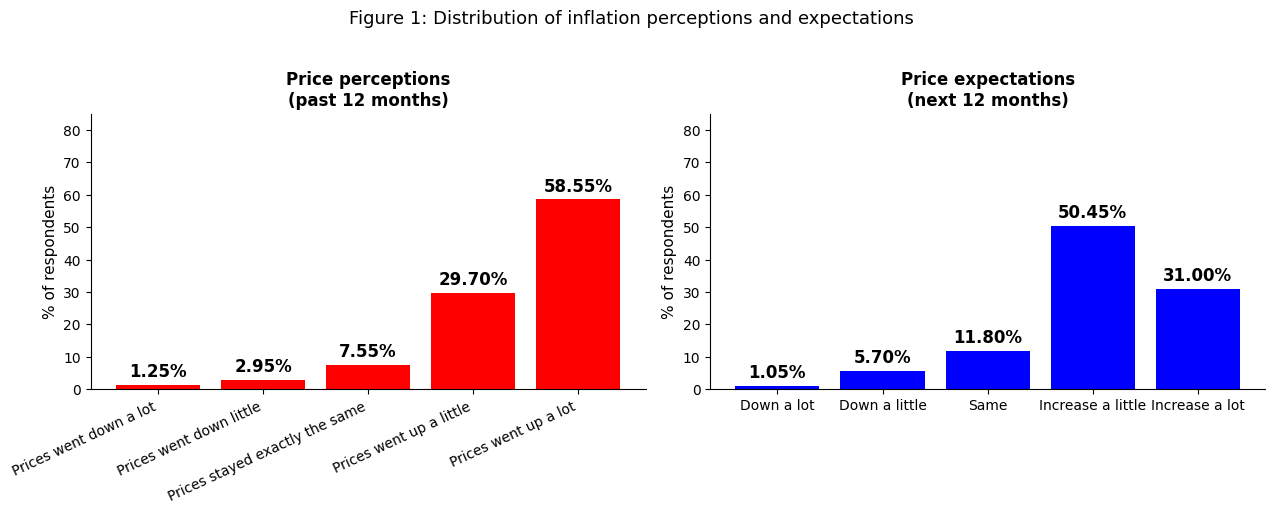

In [5]:
past_percent = [df['price_past'].value_counts().get(cat, 0) / len(df) * 100 for cat in PAST_ORDER]
exp_percent = [df['price_exp'].value_counts().get(cat, 0) / len(df) * 100 for cat in EXP_ORDER]

fig,axes = plt.subplots(1,2, figsize=(13,5))

bar1 = axes[0].bar(PAST_SHORT, past_percent,color='red',linewidth=0.8)

axes[0].bar_label(bar1, fmt='%.2f%%', padding=3, fontsize=12, fontweight='bold')

axes[0].set_title('Price perceptions\n(past 12 months)', fontweight='bold')
axes[0].set_ylabel('% of respondents')
axes[0].set_ylim(0, 85)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xticks(range(len(PAST_ORDER)))
axes[0].set_xticklabels(PAST_ORDER, rotation=25, ha='right')


bar2 = axes[1].bar(EXP_SHORT, exp_percent,color='blue', linewidth=0.8)
axes[1].bar_label(bar2, fmt='%.2f%%', padding=3, fontsize=12, fontweight='bold')
axes[1].set_title('Price expectations\n(next 12 months)', fontweight='bold')
axes[1].set_ylabel('% of respondents')
axes[1].set_ylim(0, 85)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Figure 1: Distribution of inflation perceptions and expectations',fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure1_distribuution_perceptions_expectations.png', dpi=300, bbox_inches='tight')
plt.show()


**Interpretation:** 88.3% reported prices rising; 81.5% expect further rises. The extreme category dominates both panels, consistent with the well-documented tendency to overestimate inflation.

## Figure 2 - Household coping strategies

**What we do:** show adoption rates for each strategy, and how many households used more than one simultaneously.


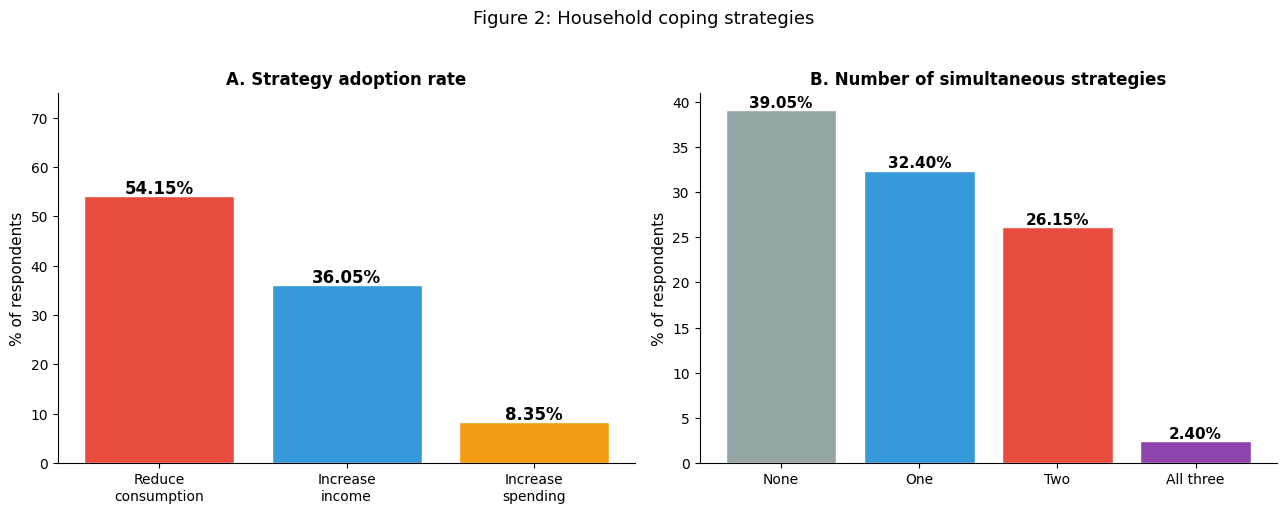

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Panel A: adoption rate of each strategy 
strategy_labels = ['Reduce\nconsumption', 'Increase\nincome', 'Increase\nspending']
strategy_percentages   = [df['reduced'].mean() * 100, df['increased_income'].mean() * 100, df['increased_spending'].mean() * 100]
strategy_colors = ['#e74c3c', '#3498db', '#f39c12']

bar_a = axes[0].bar(strategy_labels, strategy_percentages,color=strategy_colors, edgecolor='white')

for bar, val in zip(bar_a, strategy_percentages):
    axes[0].text(bar.get_x() + bar.get_width() / 2,val + 0.5, 
                 f'{val:.2f}%',ha='center', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, 75)
axes[0].set_ylabel('% of respondents')
axes[0].set_title('A. Strategy adoption rate', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

#Panel B: number of simultaneous strategies 
#value_counts() counts how many respondents used 0, 1, 2, or 3 strategies
n_counts = df['n_strategies'].value_counts()
n_percentages   = n_counts / len(df) * 100
n_labels = ['None', 'One', 'Two', 'All three']
n_colors = ['#95a5a6', '#3498db', '#e74c3c', '#8e44ad']

bar_b = axes[1].bar(n_labels, n_percentages, color=n_colors, edgecolor='white')

for bar, val in zip(bar_b, n_percentages):
    axes[1].text(bar.get_x() + bar.get_width() / 2,val + 0.3, 
                 f'{val:.2f}%',ha='center', fontsize=11, fontweight='bold')

axes[1].set_ylabel('% of respondents')
axes[1].set_title('B. Number of simultaneous strategies', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Figure 2: Household coping strategies', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure2_households_coping_strategies.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
test_pairs = [
    ('Income vs past perception', 'income_num', 'price_past_num'),
    ('Income vs future expectation', 'income_num', 'price_exp_num'),
    ('Past vs future', 'price_past_num','price_exp_num'),
    ('Age vs past perception', 'age_num', 'price_past_num'),
    ('Age vs future expectation', 'age_num', 'price_exp_num'),
]

print(f'Significance level: alpha = {ALPHA}')
print()
header = f'{"Comparison":<34} {"Spearman r":>11} {"p-value":>8} {"Kendall tau-b":>14} {"p-value":>8} {"Same decision?":>16}'
print(header)
print('-' * len(header))

for label, x, y in test_pairs:
    r_s, p_s = stats.spearmanr(df[x], df[y])
    t_k, p_k = stats.kendalltau(df[x], df[y])
    dec_spearman = 'Reject H0'  if p_s < ALPHA else 'Fail to reject'
    dec_kendall = 'Reject H0'  if p_k < ALPHA else 'Fail to reject'
    same  = 'YES'        if dec_spearman == dec_kendall else 'NO'
    print(f'{label:<34} {r_s:>11.4f} {p_s:>8.4f} {t_k:>14.4f} {p_k:>8.4f} {same:>16}')

print('\nBoth methods reach the identical decision at alpha = 0.05 for every test.')
print('Spearman r is reported in the main figures; Kendall tau-b is the robustness check.\n')
print('Note: Kendall tau-b values are smaller in magnitude than Spearman r — this is expected.')
print('The two statistics are not directly comparable in size, only in sign and significance.')

Significance level: alpha = 0.05

Comparison                          Spearman r  p-value  Kendall tau-b  p-value   Same decision?
------------------------------------------------------------------------------------------------
Income vs past perception              -0.0695   0.0019        -0.0601   0.0017              YES
Income vs future expectation           -0.0764   0.0006        -0.0647   0.0006              YES
Past vs future                          0.5184   0.0000         0.4886   0.0000              YES
Age vs past perception                 -0.0035   0.8743        -0.0036   0.8585              YES
Age vs future expectation              -0.0336   0.1329        -0.0301   0.1268              YES

Both methods reach the identical decision at alpha = 0.05 for every test.
Spearman r is reported in the main figures; Kendall tau-b is the robustness check.

Note: Kendall tau-b values are smaller in magnitude than Spearman r — this is expected.
The two statistics are not directly comp

## Figure 3 — Income vs perceptions/expectations 
**What we do:** For each income group we show whether there is relation (positive/negative/no relation) between income and perceptions and expectations using Spearman correlation coefficient. 

In [8]:
from itertools import combinations

# Test 1 Spearman correlation coefficent

r_past, p_past = stats.spearmanr(df['income_num'], df['price_past_num'])
r_exp, p_exp = stats.spearmanr(df['income_num'], df['price_exp_num'])

def decision(p):
    return 'Reject H0' if p < ALPHA else 'Fail to reject H0'

print('\nTest 1: Spearman rank correlation (alpha=', ALPHA,')')
print(' HO: no monotonic relationship between income and price perceptions')
print(f' Income vs past perception: r={r_past:.3f}, p={p_past:.3f} -> {decision(p_past)}')
print(f' Income vs expected perception: r={r_exp:.3f}, p={p_exp:.3f} -> {decision(p_exp)}')
print()

# Test 2 Kruskal-Wallis 
income_groups_past = [df[df['income'] == q]['price_past_num'].values for q in INCOME_ORDER]
income_groups_exp = [df[df['income'] == q]['price_exp_num'].values for q in INCOME_ORDER]

H_past_income, p_kw_past = stats.kruskal(*income_groups_past)
H_exp_income, p_kw_exp = stats.kruskal(*income_groups_exp)

print('Test 2: Kruskal-Wallis test (alpha=', ALPHA,')')
print(' HO: All five income groups have the same distribution of price perceptions')
print(f' Income vs past perception: H={H_past_income:.3f}, p={p_kw_past:.3f}  {decision(p_kw_past)}')
print(f' Income vs expected perception: H={H_exp_income:.3f}, p={p_kw_exp:.3f}  {decision(p_kw_exp)}')
print()

# Test 3: Mann-Whitney U test for reduced consumption by price perception
quintile_labels = ['1st', '2nd', '3rd', '4th', '5th']
pairs = list (combinations(range(5),2))
n_pairs = len(pairs)

print(f'Test 3: Mann-Whitney U Bonferroni corrected test for reduced consumption by price perception (alpha={ALPHA})')
print(' H0: per pair the two quintiles share the same distribution')
print(f'Bonferroni threshold alpha /npairs = {ALPHA} /{n_pairs} = {ALPHA / n_pairs:.4f} (raw p-value)')
print()
header = f'{"Pair":<14} {"U statistic":<12} {"raw p-value":>10} {"Bonferroni":>16} {"Decision":>16}'
print(header)
print('-' + '-' * (len(header) - 2))
for i,j in pairs:
    group1, group2 = income_groups_past[i], income_groups_past[j]
    U, p_raw = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    p_bonf = min(p_raw * n_pairs,1.0)
    decision_mu = 'Reject H0' if p_bonf < ALPHA else 'Fail to reject H0'
    label = f'{quintile_labels[i]} vs {quintile_labels[j]}'
    print(f' {label:<14} {U:<14.0f} {p_raw:>10.4f} {p_bonf:>16.4f} {decision_mu:>16}')



Test 1: Spearman rank correlation (alpha= 0.05 )
 HO: no monotonic relationship between income and price perceptions
 Income vs past perception: r=-0.070, p=0.002 -> Reject H0
 Income vs expected perception: r=-0.076, p=0.001 -> Reject H0

Test 2: Kruskal-Wallis test (alpha= 0.05 )
 HO: All five income groups have the same distribution of price perceptions
 Income vs past perception: H=15.488, p=0.004  Reject H0
 Income vs expected perception: H=12.428, p=0.014  Reject H0

Test 3: Mann-Whitney U Bonferroni corrected test for reduced consumption by price perception (alpha=0.05)
 H0: per pair the two quintiles share the same distribution
Bonferroni threshold alpha /npairs = 0.05 /10 = 0.0050 (raw p-value)

Pair           U statistic  raw p-value       Bonferroni         Decision
------------------------------------------------------------------------
 1st vs 2nd     71382              0.3922           1.0000 Fail to reject H0
 1st vs 3rd     77890              0.4557           1.0000 Fa

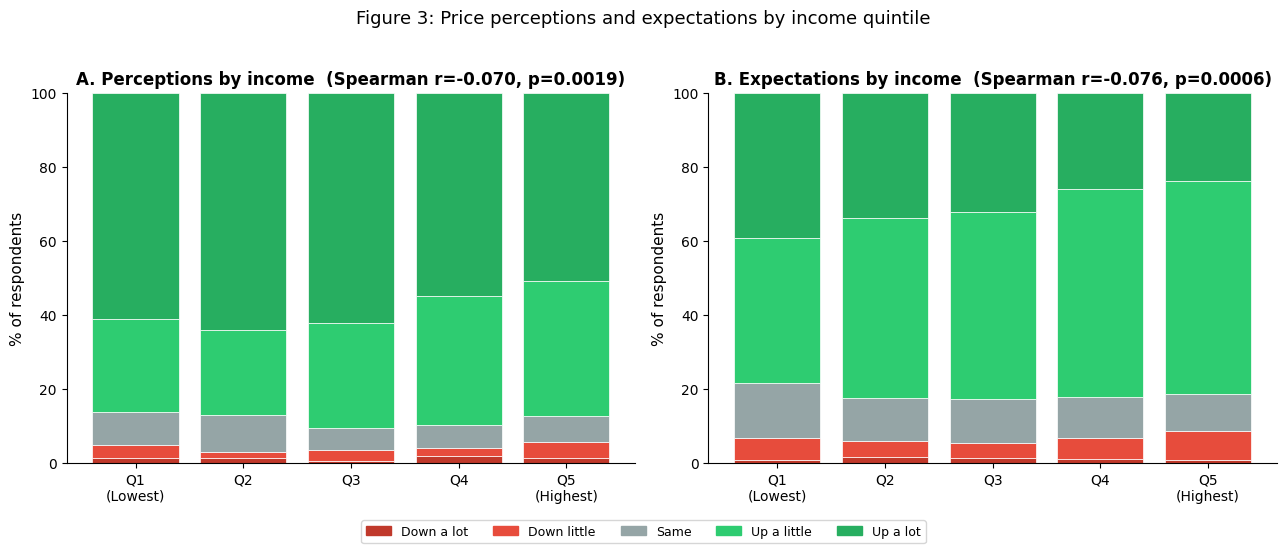

In [9]:
def plot_stacked(ax, x_col, y_col, x_order, x_labels, y_order, y_labels, title):
    ct = pd.crosstab(df[x_col], df[y_col], normalize='index') * 100
    ct = ct.reindex(index=x_order).reindex(columns=y_order, fill_value=0)
    bottoms = np.zeros(len(x_order))
    for cat, color, label in zip(y_order, DIV_COLORS, y_labels):
        vals = ct[cat].values
        ax.bar(x_labels, vals, bottom=bottoms, color=color, label=label,
               edgecolor='white', linewidth=0.5)
        bottoms += vals
    ax.set_ylim(0, 100)
    ax.set_ylabel('% of respondents')
    ax.set_title(title, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_stacked(axes[0], 'income', 'price_past', INCOME_ORDER, INCOME_SHORT,
             PAST_ORDER, PAST_SHORT,
             f'A. Perceptions by income  (Spearman r={r_past:.3f}, p={p_past:.4f})')

plot_stacked(axes[1], 'income', 'price_exp', INCOME_ORDER, INCOME_SHORT,
             EXP_ORDER, EXP_SHORT,
             f'B. Expectations by income  (Spearman r={r_exp:.3f}, p={p_exp:.4f})')

handles = [mpatches.Patch(color=col, label=lab) for col, lab in zip(DIV_COLORS, PAST_SHORT)]
fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.06), fontsize=9)

plt.suptitle('Figure 3: Price perceptions and expectations by income quintile', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure3_perceptions_expectations_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 4 - Cross country comparison

In [10]:
groups_past = [df[df['country_code']==c ]['price_past_num'].values for c in ['DE', 'EL', 'ES', 'PT']] 
groups_exp = [df[df['country_code']==c ]['price_exp_num'].values for c in ['DE', 'EL', 'ES', 'PT']] 

H_past, p_kw_past_country = stats.kruskal(*groups_past)
H_exp, p_kw_exp_country = stats.kruskal(*groups_exp)

print('H0: the distribution of perception is identical across all four countries')
print('HA: at least one country differs in distribution of perception\n ')
print(f'Kruskal-Wallis across countries (alpha={ALPHA})')
print(f' Past: H = {H_past:.2f}, p = {p_kw_past_country:.3e} {decision(p_kw_past_country)} ')
print(f' Expected: H = {H_exp:.2f}, p = {p_kw_exp_country:.3e}  {decision(p_kw_exp_country)} ')


H0: the distribution of perception is identical across all four countries
HA: at least one country differs in distribution of perception
 
Kruskal-Wallis across countries (alpha=0.05)
 Past: H = 146.14, p = 1.794e-31 Reject H0 
 Expected: H = 69.80, p = 4.712e-15  Reject H0 


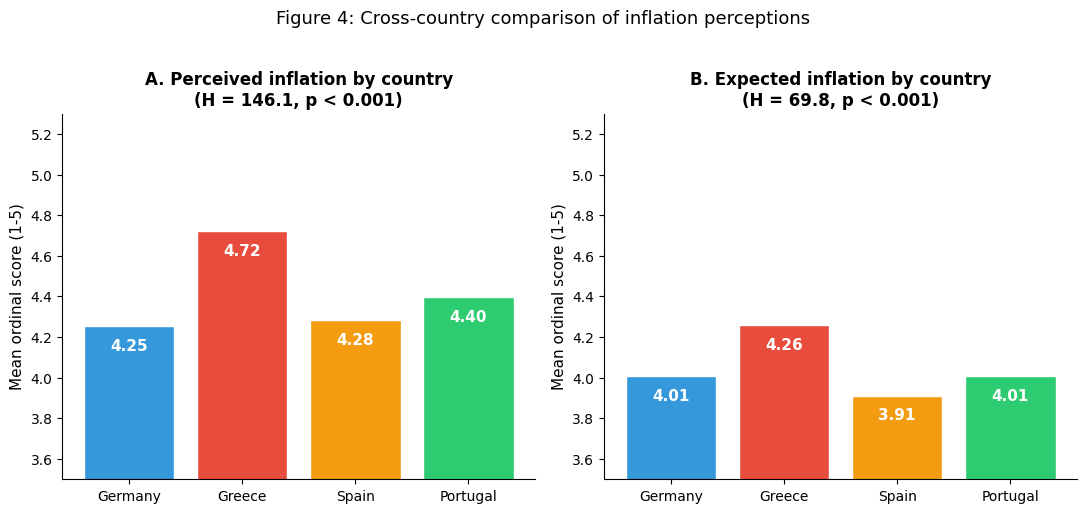

In [11]:
countries = ['DE','EL','ES','PT']
country_names = ['Germany','Greece','Spain','Portugal']
country_colors = ['#3498db','#e74c3c','#f39c12','#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, var, H, p_kw, title in [
    (axes[0], 'price_past_num', H_past, p_kw_past_country,
     f'A. Perceived inflation by country\n(H = {H_past:.1f}, p < 0.001)'),
    (axes[1], 'price_exp_num',  H_exp,  p_kw_exp_country,
     f'B. Expected inflation by country\n(H = {H_exp:.1f}, p < 0.001)')
]:
    means = [df[df['country_code']==c][var].mean() for c in countries]
    sems  = [df[df['country_code']==c][var].sem()  for c in countries]
    bars  = ax.bar(country_names, means, color=country_colors, edgecolor='white')
    for bar, m in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, m-0.12, f'{m:.2f}',
                ha='center', fontsize=11, fontweight='bold', color='white')
    ax.set_ylim(3.5, 5.3)
    ax.set_ylabel('Mean ordinal score (1-5)')
    ax.set_title(title, fontweight='bold')
    ax.axhline(y=3, color='gray', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Figure 4: Cross-country comparison of inflation perceptions', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure4_cross_country_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5 - Consequences of perceived inflation
**Tests:** Chi-square, spearman correlation 

In [12]:
chi_contigency = pd.crosstab(df['price_past'], df['reduced_consumption'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(chi_contigency)
r_situation, p_situation = stats.spearmanr(df['price_past_num'], df['sit_last_num'])

print(f'chi_contingency:\n{chi_contigency}')
print(f'\nChi-squared test for association between price perception and reduced consumption (alpha={ALPHA})')
print('H0: price perception and reduced consumption are independent')
print(f'Chi2 statistic: {chi2:.3f}, p-value: {p_chi2:.3e} -> {decision(p_chi2)}')

print()

print(f'All expected cell counts >= 5: {(expected >= 5).all()}')
print()
print(f' Spearman correlation (alpha = {ALPHA})')
print('H0: no monotonic relationship between price perception and strategy adoption')
print(f' r = {r_situation:.3f}, p-value: {p_situation:.3e} -> {decision(p_situation)}')

chi_contingency:
reduced_consumption             No changes  Yes (cheaper or fewer goods)
price_past                                                              
Prices stayed exactly the same         111                            40
Prices went down a lot                  12                            13
Prices went down little                 28                            31
Prices went up a little                295                           299
Prices went up a lot                   471                           700

Chi-squared test for association between price perception and reduced consumption (alpha=0.05)
H0: price perception and reduced consumption are independent
Chi2 statistic: 65.057, p-value: 2.503e-13 -> Reject H0

All expected cell counts >= 5: True

 Spearman correlation (alpha = 0.05)
H0: no monotonic relationship between price perception and strategy adoption
 r = -0.317, p-value: 6.176e-48 -> Reject H0


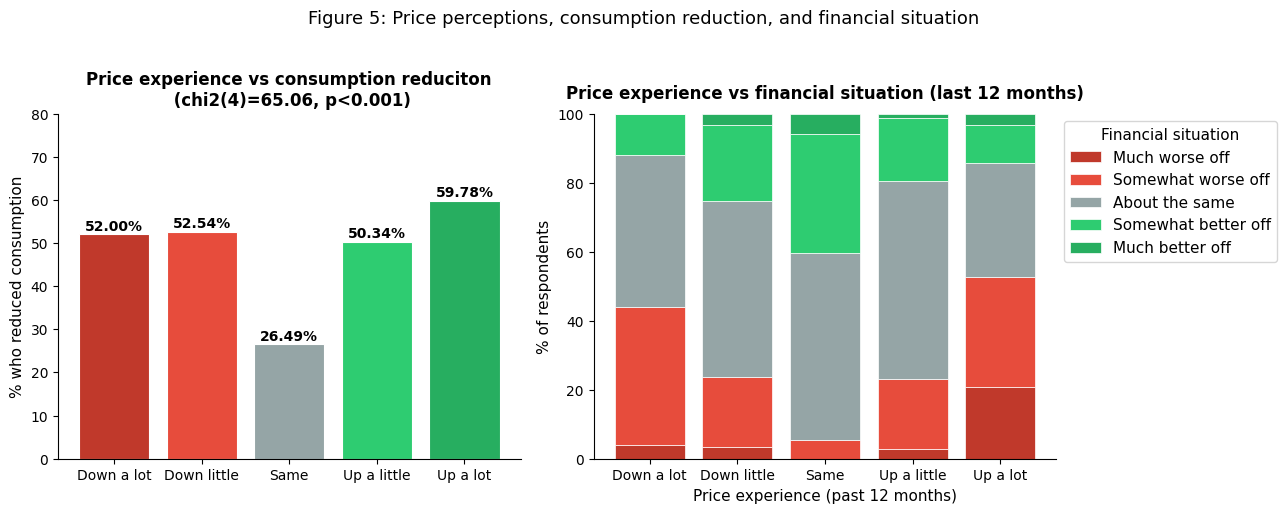

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Panel A
contingency_red = pd.crosstab(df['price_past'], df['reduced_consumption'], normalize='index') * 100
contingency_red = contingency_red.reindex(index=PAST_ORDER, fill_value=0)
percentage_reduced = contingency_red['Yes (cheaper or fewer goods)'].values

bar_a = axes[0].bar(PAST_SHORT, percentage_reduced, color=DIV_COLORS, edgecolor='white', linewidth=0.8)
for bar, val in zip(bar_a, percentage_reduced):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].set_ylim(0,80)
    axes[0].set_ylabel('% who reduced consumption')
    axes[0].set_title(f'Price experience vs consumption reduciton\n (chi2({dof})={chi2:.2f}, p<0.001)', fontweight='bold') 
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

#Panel B
situation_cats = ['Much worse off', 'Somewhat worse off', 'About the same', 'Somewhat better off', 'Much better off']
situation_labels = ['Much worse off', 'Somewhat worse off', 'About the same', 'Somewhat better off', 'Much better off']
contingency_sit = pd.crosstab(df['price_past'], df['sit_last_12months'], normalize='index') * 100
contingency_sit = contingency_sit.reindex(index=PAST_ORDER).reindex(columns=situation_cats, fill_value=0)

bottoms = np.zeros(len(PAST_ORDER))
for cat, color, label in zip(situation_cats, DIV_COLORS, situation_labels):
    vals = contingency_sit[cat].values
    axes[1].bar(PAST_SHORT, vals, bottom=bottoms, color=color, label=label,
                edgecolor='white', linewidth=0.5)
    bottoms += vals

axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% of respondents')
axes[1].set_xlabel('Price experience (past 12 months)')
axes[1].set_title('Price experience vs financial situation (last 12 months)', fontweight='bold', y=1.02)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend(title='Financial situation', loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('Figure 5: Price perceptions, consumption reduction, and financial situation', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure5_price_perception_consumption_situation.png', dpi=300, bbox_inches='tight')
plt.show()


## Figure 6 - Past predicts future + age effect

In [16]:
r_anchor, p_anchor = stats.spearmanr(df['price_past_num'], df['price_exp_num'])
r_age_past, p_age_past = stats.spearmanr(df['age_num'], df['price_past_num'])
r_age_exp, p_age_exp = stats.spearmanr(df['age_num'], df['price_exp_num'])

print('Past perception vs. expected perception')
print('  H0: no monotonic association between past perceptions and future expectations (rho = 0)')
print('  H1: households who perceived higher past inflation expect higher future inflation (rho > 0)')
print(f'  Result: r = {r_anchor:.3f}, p = {p_anchor:.4f}  -->  {decision(p_anchor)}')
print(f'  Interpretation: rho = {r_anchor:.3f} — moderate-to-strong anchoring effect.')
print(f'  Past perception explains approx {r_anchor**2*100:.1f}% of variance in future expectation.')
print()
print('Age vs price perception:') 
print('  H0: no monotonic association between age group and inflation perception (rho = 0)')
print('  H1: age is associated with inflation perception or expectation (rho != 0)')
print(f'  Age vs past perception:    r = {r_age_past:.3f}, p = {p_age_past:.4f}  -->  {decision(p_age_past)}')
print(f'  Age vs future expectation: r = {r_age_exp:.3f},  p = {p_age_exp:.4f}  -->  {decision(p_age_exp)}')
print(f'  Interpretation: both results are not significant at alpha = {ALPHA}.')
print('  H3 is rejected — age does not predict inflation perception in this sample.')

Past perception vs. expected perception
  H0: no monotonic association between past perceptions and future expectations (rho = 0)
  H1: households who perceived higher past inflation expect higher future inflation (rho > 0)
  Result: r = 0.518, p = 0.0000  -->  Reject H0
  Interpretation: rho = 0.518 — moderate-to-strong anchoring effect.
  Past perception explains approx 26.9% of variance in future expectation.

Age vs price perception:
  H0: no monotonic association between age group and inflation perception (rho = 0)
  H1: age is associated with inflation perception or expectation (rho != 0)
  Age vs past perception:    r = -0.004, p = 0.8743  -->  Fail to reject H0
  Age vs future expectation: r = -0.034,  p = 0.1329  -->  Fail to reject H0
  Interpretation: both results are not significant at alpha = 0.05.
  H3 is rejected — age does not predict inflation perception in this sample.


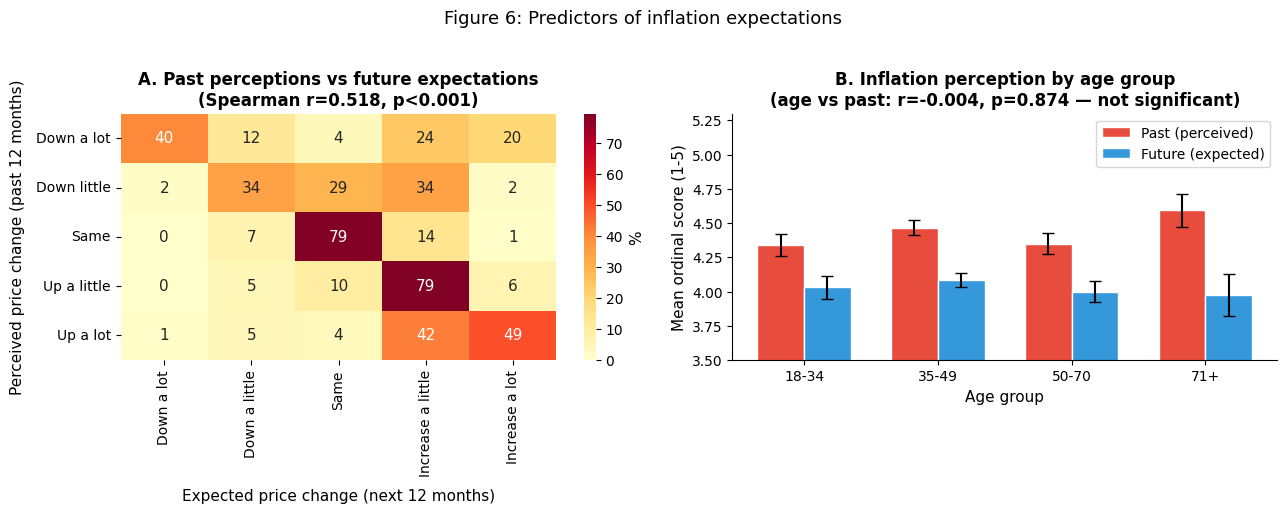

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_heat = pd.crosstab(df['price_past'], df['price_exp'], normalize='index') * 100
ct_heat = ct_heat.reindex(index=PAST_ORDER, columns=EXP_ORDER, fill_value=0)

sns.heatmap(
    ct_heat, ax=axes[0],
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': '%'},
    xticklabels=EXP_SHORT,
    yticklabels=PAST_SHORT
)
axes[0].set_xlabel('Expected price change (next 12 months)', labelpad=8)
axes[0].set_ylabel('Perceived price change (past 12 months)', labelpad=8)
axes[0].set_title(
    f'A. Past perceptions vs future expectations\n'
    f'(Spearman r={r_anchor:.3f}, p<0.001)',
    fontweight='bold'
)
axes[0].tick_params(axis='y', rotation=0)

# Panel B: Grouped bars by age 
# Compute mean and SEM for each age group, for both price variables
# Mean is computed for visual comparison only — the Spearman test above
# does not rely on means, so this is descriptive, not inferential
age_means_past = [df[df['age_group']==a]['price_past_num'].mean() for a in AGE_ORDER]
age_means_exp = [df[df['age_group']==a]['price_exp_num'].mean()  for a in AGE_ORDER]
age_sems_past = [df[df['age_group']==a]['price_past_num'].sem()  for a in AGE_ORDER]
age_sems_exp = [df[df['age_group']==a]['price_exp_num'].sem()   for a in AGE_ORDER]

# np.arange(4) creates positions [0, 1, 2, 3] on the x-axis
# w = bar width: two bars per position, each shifted by half-width
# so they sit side by side without overlapping
x, w = np.arange(4), 0.35

# x - w/2: shifts the past-perception bar to the LEFT of centre
# x + w/2: shifts the future-expectation bar to the RIGHT of centre
axes[1].bar(x-w/2, age_means_past, w,
            color='#e74c3c', label='Past (perceived)', edgecolor='white')
axes[1].bar(x+w/2, age_means_exp,  w,
            color='#3498db', label='Future (expected)', edgecolor='white')

# 95% CI error bars: 1.96 × SEM on each side of the mean
# fmt='none': draws only the error bar, no central dot marker
# capsize=4: adds horizontal caps at the end of each error bar
axes[1].errorbar(x-w/2, age_means_past, yerr=[1.96*s for s in age_sems_past],
                 fmt='none', color='black', capsize=4)
axes[1].errorbar(x+w/2, age_means_exp,  yerr=[1.96*s for s in age_sems_exp],
                 fmt='none', color='black', capsize=4)

# set_xticks + set_xticklabels: replaces numeric positions [0,1,2,3]
# with readable age group labels on the x-axis
axes[1].set_xticks(x)
axes[1].set_xticklabels(['18-34','35-49','50-70','71+'])
axes[1].set_ylim(3.5, 5.3)
axes[1].set_ylabel('Mean ordinal score (1-5)')
axes[1].set_xlabel('Age group')
axes[1].set_title(
    f'B. Inflation perception by age group\n'
    f'(age vs past: r={r_age_past:.3f}, p={p_age_past:.3f} — not significant)',
    fontweight='bold'
)
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Figure 6: Predictors of inflation expectations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()